# Ecuacion de calor con condiciones de Dirichlet (Actividad)

$$\frac{\partial u}{\partial t} + a\frac{\partial u}{\partial x} = D\frac{\partial^2 u}{\partial x^2},\quad x\in(0,1),\; t\ge 0$$

con $u(0,t)=u(1,t)=0$ y $u(x,0)=\sin(4\pi x)$.

Karla Rebeca Munguía Romero

Cristobal Medina Meza

Gabriel Eduardo Meléndez Zavala

Gabriel Reynoso Escamilla

Santiago Mora Cruz

Guillermo Villegas Morales

## Libraries

In [54]:
import numpy as np
from numpy.linalg import solve, norm
from numpy import pi, exp, sin, cos
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.animation as animation
import pandas as pd
from pathlib import Path

## Archivos de solucion exacta (CSV)


In [55]:
base_dir = Path("./datos")
exact_files = {
    (1.0, 20): "uexmp_1_2_20.csv",
    (1.0, 40): "uexmp_1_2_40.csv",
    (0.01, 20): "uexmp_001_2_20.csv",
    (0.01, 40): "uexmp_001_2_40.csv",
}

def load_exact(D, N):
    key = (float(D), int(N))
    if key not in exact_files:
        raise KeyError(f"No hay archivos configurados para D={D}, N={N}")
    exact_path = base_dir / exact_files[key]
    if not exact_path.exists():
        raise FileNotFoundError(f"No se encontro: {exact_path}")
    u_exact_grid = np.loadtxt(exact_path, delimiter=",")
    if u_exact_grid.shape[0] != (N + 1):
        u_exact_grid = u_exact_grid.T
    u_exact = u_exact_grid
    return u_exact, u_exact_grid

In [56]:
u_exact, u_exact_grid = load_exact(D=1.0, N=20)

In [57]:
u_exact_grid.shape

(21, 1001)

In [58]:
u_exact.shape

(21, 1001)

## Parametros del problema

In [59]:
a = 2.0
D_values = [1.0, 0.01]
N_values = [20, 40]

tmin, tmax = 0.0, 1.0
dt = 0.001

times_to_plot = [0.06, 0.1, 1.0]


def f(x):
    return np.sin(4*np.pi*x)

## Esquemas

Se usan diferencias centradas para $u_x$ y $u_{xx}$.

![WhatsApp Image 2026-05-15 at 08.26.36.jpeg](<attachment:WhatsApp Image 2026-05-15 at 08.26.36.jpeg>)

![1.jpeg](attachment:1.jpeg)

In [60]:
def setup_case(D, N):
    xmin, xmax = 0.0, 1.0
    dx = (xmax - xmin) / N
    x = np.linspace(xmin, xmax, N + 1)
    M = int((tmax - tmin) / dt)
    t = np.linspace(tmin, tmax, M + 1)
    s = D * dt / (dx * dx)
    alpha = a * dt / (2 * dx)
    X, T = np.meshgrid(x, t)
    vmin, vmax = -1.0, 1.0
    levels = np.linspace(vmin, vmax, 21)
    return x, t, dx, M, s, alpha, X, T, levels


def forward_euler(D, N):
    x, t, dx, M, s, alpha, X, T, levels = setup_case(D, N)
    # evitar overflow no quitar
    if s > 0.5 or abs(alpha) > 1.0:
        raise ValueError(
            f"Forward Euler unstable for D={D}, N={N}: s={s:.3f}, alpha={alpha:.3f}. "
            "Reduce dt or N."
        )
    u = np.zeros((N + 1, M + 1))
    u[:, 0] = f(x)
    for k in range(M):
        u[1:-1, k + 1] = (
            u[1:-1, k]
            - alpha * (u[2:, k] - u[:-2, k])
            + s * (u[2:, k] - 2 * u[1:-1, k] + u[:-2, k])
        )
    return u, x, t, X, T, levels


def backward_euler(D, N):
    x, t, dx, M, s, alpha, X, T, levels = setup_case(D, N)
    u = np.zeros((N + 1, M + 1))
    u[:, 0] = f(x)
    n = N - 1
    be_matrix_left = np.diag((1 + 2*s) * np.ones(n))
    for j in range(1, n - 1):
        be_matrix_left[j, j + 1] = -(alpha + s)
        be_matrix_left[j, j - 1] = (alpha - s)
    be_matrix_left[0, 1] = -(alpha + s)
    be_matrix_left[-1, -2] = (alpha - s)

    for k in range(M):
        utemp = u[1:N, k]
        utemp = solve(be_matrix_left, utemp)
        u[1:N, k + 1] = utemp
    return u, x, t, X, T, levels

def crank_nicolson(D, N):
    x, t, dx, M, s, alpha, X, T, levels = setup_case(D, N)
    u = np.zeros((N + 1, M + 1))
    u[:, 0] = f(x)
    n = N - 1
    cn_matrix_left = np.diag(2 * (1 + s) * np.ones(n))
    cn_matrix_right = np.diag(2 * (1 - s) * np.ones(n))
    for j in range(1, n - 1):
        cn_matrix_left[j, j + 1] = (alpha - s)
        cn_matrix_left[j, j - 1] = -(alpha + s)
        cn_matrix_right[j, j + 1] = -(alpha - s)
        cn_matrix_right[j, j - 1] = (alpha + s)
    cn_matrix_left[0, 1] = (alpha - s)
    cn_matrix_left[-1, -2] = -(alpha + s)
    cn_matrix_right[0, 1] = -(alpha - s)
    cn_matrix_right[-1, -2] = (alpha + s)

    for k in range(M):
        utemp = u[1:N, k]
        utemp = cn_matrix_right @ utemp
        utemp = solve(cn_matrix_left, utemp)
        u[1:N, k + 1] = utemp
    return u, x, t, X, T, levels


def error_at_times(u, u_exact_grid, t, times):
    errs = {}
    for tt in times:
        idx = int(round(tt / dt))
        e = u[:, idx] - u_exact_grid[:, idx]
        errs[tt] = {
            "L2": norm(e) / np.sqrt(u.shape[0]),
            "Linf": norm(e, ord=np.inf),
            "e": e,
        }
    return errs

## Ejecucion de los casos

Para cada par $(D, N)$ se cargan los CSV de solucion exacta, se calculan las tres aproximaciones y se comparan en $t=0.06, 0.1, 1.0$.

=== Caso D=1.0, N=20 ===


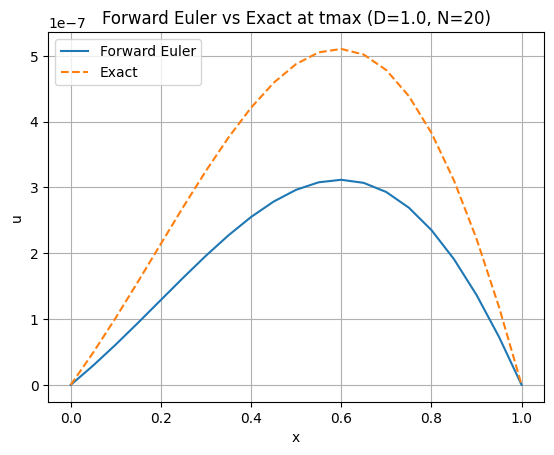

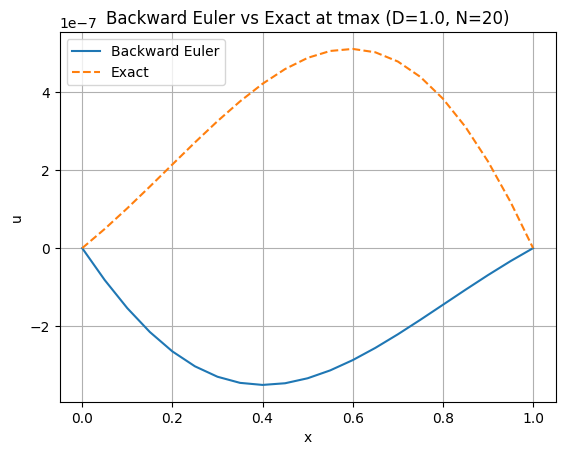

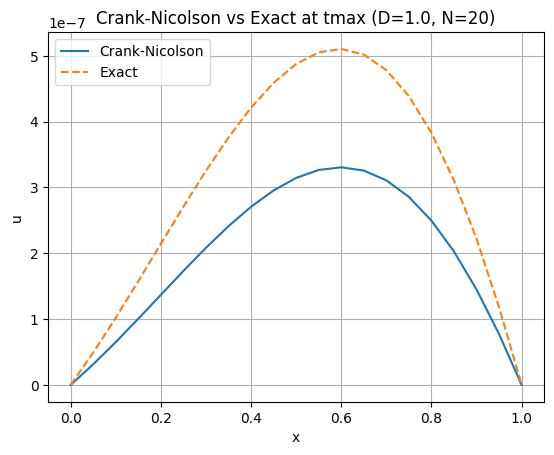

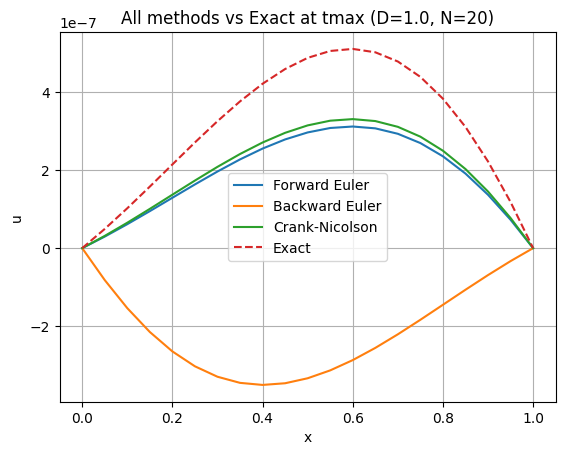

=== Caso D=1.0, N=40 ===
Error: Forward Euler unstable for D=1.0, N=40: s=1.600, alpha=0.040. Reduce dt or N.
=== Caso D=0.01, N=20 ===


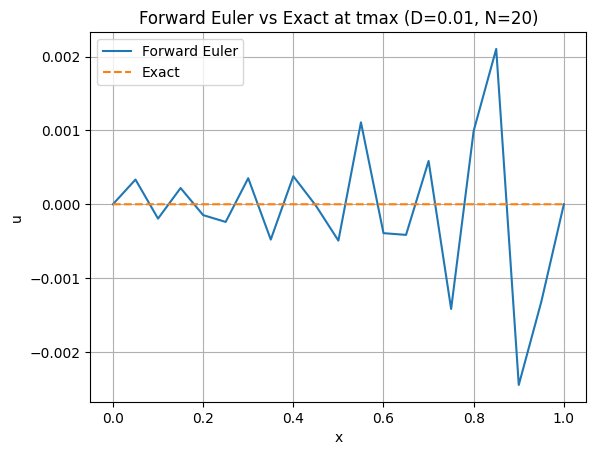

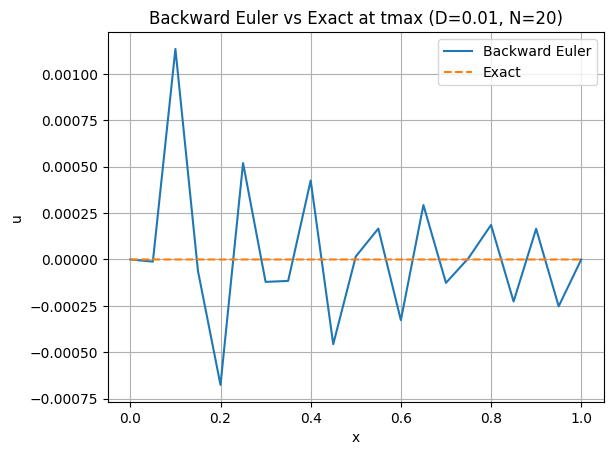

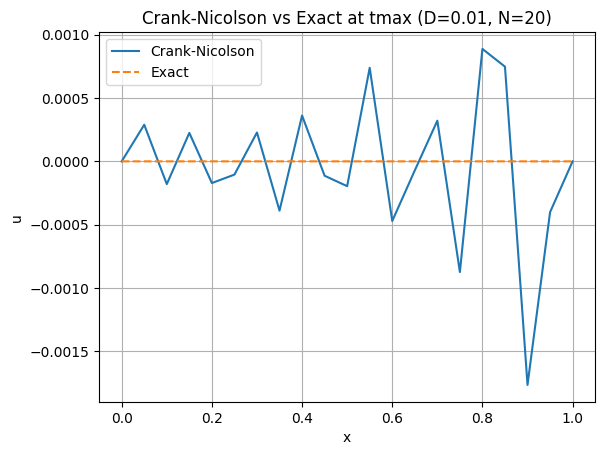

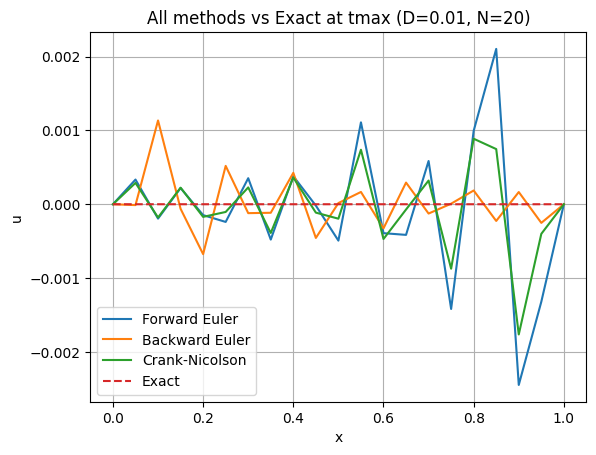

=== Caso D=0.01, N=40 ===


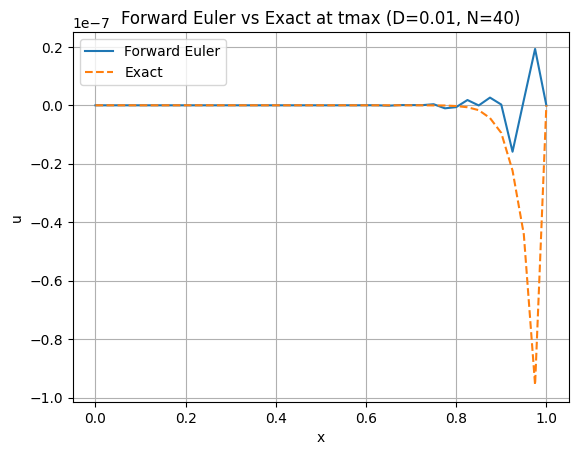

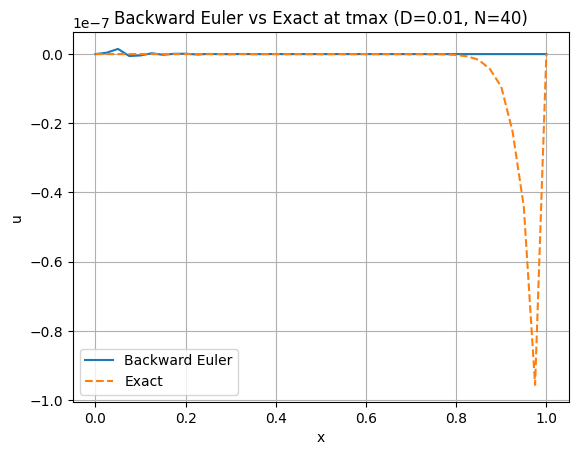

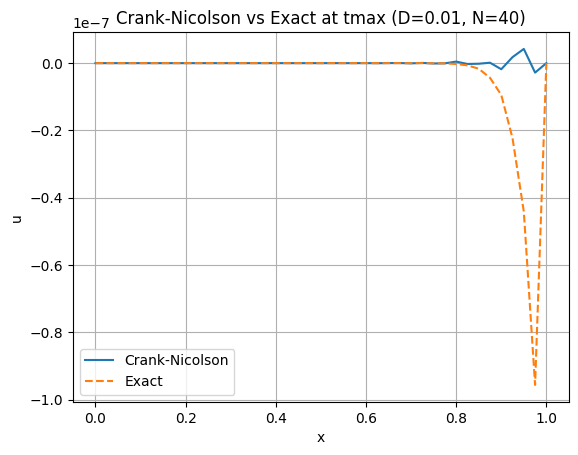

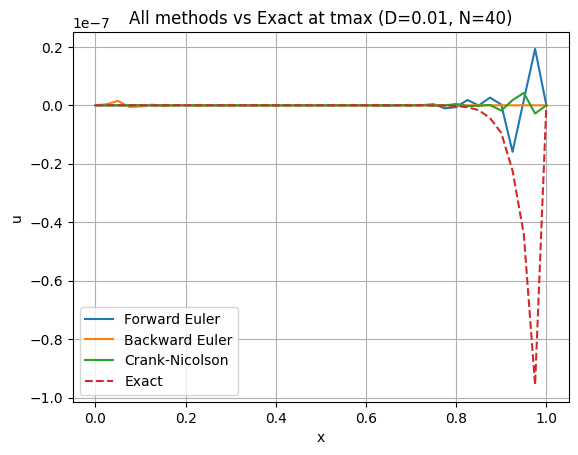

In [61]:
def run_case(D, N):
    print(f"=== Caso D={D}, N={N} ===")
    u_exact, u_exact_grid = load_exact(D, N)

    x, t, dx, M, s, r, X, T, levels = setup_case(D, N)

    if u_exact_grid.shape != (N+1, M+1):
        raise ValueError(
            f"La solucion exacta discretizada tiene forma {u_exact_grid.shape}, se esperaba {(N+1, M+1)}"
        )

    try:
        u_fwd, x, t, X, T, levels = forward_euler(D, N)
        u_bwd, x, t, X, T, levels = backward_euler(D, N)
        u_cn, x, t, X, T, levels = crank_nicolson(D, N)
    except ValueError as e:
        print(f"Error: {e}")
        return

    for u, name in [(u_fwd, "Forward Euler"), (u_bwd, "Backward Euler"), (u_cn, "Crank-Nicolson")]:
        fig, ax = plt.subplots()
        ax.plot(x, u[:, M], label=name)
        ax.plot(x, u_exact_grid[:, M], label="Exact", linestyle="--")
        ax.set(title=f"{name} vs Exact at tmax (D={D}, N={N})", xlabel="x", ylabel="u")
        ax.grid()
        ax.legend()
        plt.show()

    fig, ax = plt.subplots()
    ax.plot(x, u_fwd[:, M], label="Forward Euler")
    ax.plot(x, u_bwd[:, M], label="Backward Euler")
    ax.plot(x, u_cn[:, M], label="Crank-Nicolson")
    ax.plot(x, u_exact_grid[:, M], label="Exact", linestyle="--")
    ax.set(title=f"All methods vs Exact at tmax (D={D}, N={N})", xlabel="x", ylabel="u")
    ax.grid()
    ax.legend()
    plt.show()


for D in D_values:
    for N in N_values:
        run_case(D, N)